In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

print("wfdb version:", wfdb.__version__)
print("All libraries loaded!")

wfdb version: 4.3.1
All libraries loaded!


In [2]:
# Download ECG record from PhysioNet MIT-BIH database
# Record 100 is the most commonly used for learning

record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print("Record name:", record.record_name)
print("Number of signals:", record.n_sig)
print("Signal names:", record.sig_name)
print("Sampling frequency:", record.fs, "Hz")
print("Number of samples:", record.sig_len)
print("Duration:", record.sig_len / record.fs, "seconds")
print("\nAnnotation symbols (first 20):", annotation.symbol[:20])
print("Total beats annotated:", len(annotation.symbol))

Record name: 100
Number of signals: 2
Signal names: ['MLII', 'V5']
Sampling frequency: 360 Hz
Number of samples: 650000
Duration: 1805.5555555555557 seconds

Annotation symbols (first 20): ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
Total beats annotated: 2274


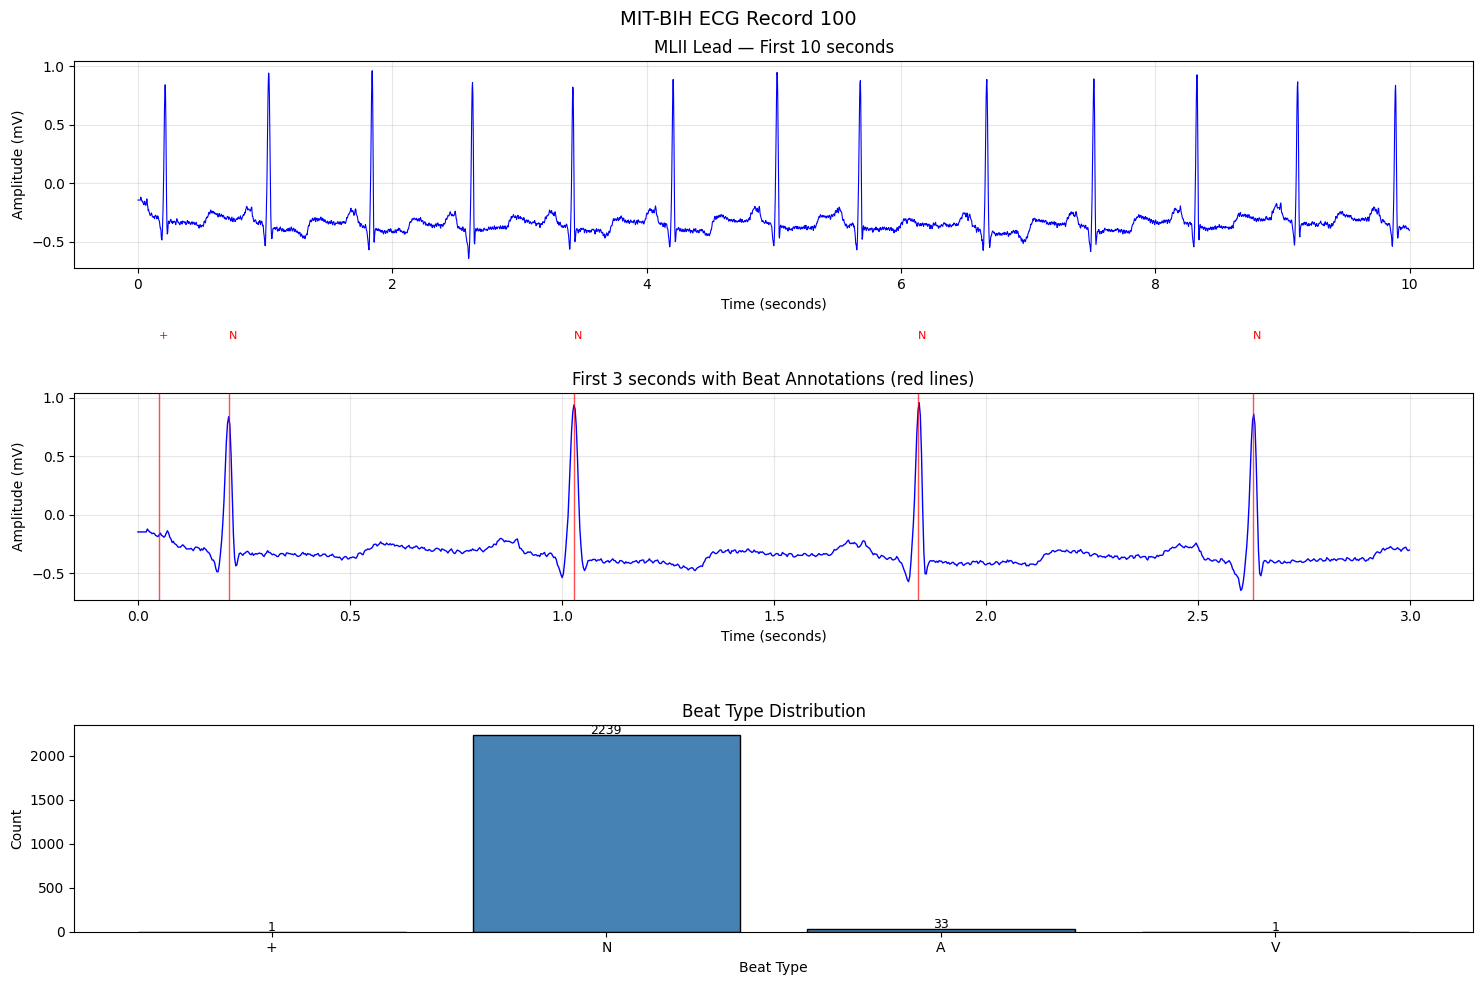

In [3]:
# Visualize the ECG signal

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('MIT-BIH ECG Record 100', fontsize=14)

# Plot 1 — First 10 seconds of ECG
samples_10s = 10 * record.fs  # 3600 samples
time = np.arange(samples_10s) / record.fs

axes[0].plot(time, record.p_signal[:samples_10s, 0], 
             color='blue', linewidth=0.8)
axes[0].set_title('MLII Lead — First 10 seconds')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

# Plot 2 — First 3 seconds with beat annotations
samples_3s = 3 * record.fs
time_3s = np.arange(samples_3s) / record.fs

axes[1].plot(time_3s, record.p_signal[:samples_3s, 0],
             color='blue', linewidth=1)

# Mark beat locations
for i, sample in enumerate(annotation.sample):
    if sample < samples_3s:
        axes[1].axvline(x=sample/record.fs, color='red', 
                       alpha=0.7, linewidth=1)
        axes[1].text(sample/record.fs, 1.5, 
                    annotation.symbol[i], fontsize=8, color='red')

axes[1].set_title('First 3 seconds with Beat Annotations (red lines)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, alpha=0.3)

# Plot 3 — Beat type distribution
from collections import Counter
beat_counts = Counter(annotation.symbol)
labels = list(beat_counts.keys())
counts = list(beat_counts.values())

axes[2].bar(labels, counts, color='steelblue', edgecolor='black')
axes[2].set_title('Beat Type Distribution')
axes[2].set_xlabel('Beat Type')
axes[2].set_ylabel('Count')
for i, (l, c) in enumerate(zip(labels, counts)):
    axes[2].text(i, c + 5, str(c), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Extract individual heartbeats from ECG signal

def extract_beats(record, annotation, window_size=180):
    """
    Extract individual heartbeats centered around each R-peak.
    window_size = number of samples around each beat (180 = 0.5 seconds at 360Hz)
    """
    beats = []
    labels = []
    ecg_signal = record.p_signal[:, 0]  # Use MLII lead
    
    # Only keep Normal (N) and Abnormal (A) beats
    valid_symbols = {'N': 0, 'A': 1}
    
    for i, sample in enumerate(annotation.sample):
        symbol = annotation.symbol[i]
        
        if symbol not in valid_symbols:
            continue
            
        # Extract window around beat
        start = sample - window_size // 2
        end = sample + window_size // 2
        
        # Skip beats too close to edges
        if start < 0 or end > len(ecg_signal):
            continue
            
        beat = ecg_signal[start:end]
        beats.append(beat)
        labels.append(valid_symbols[symbol])
    
    return np.array(beats), np.array(labels)

# Extract beats
beats, labels = extract_beats(record, annotation)

print("Total beats extracted:", len(beats))
print("Beat shape:", beats.shape)
print("Normal beats (0):", np.sum(labels == 0))
print("Abnormal beats (1):", np.sum(labels == 1))
print("Each beat has", beats.shape[1], "samples =", 
      beats.shape[1]/record.fs*1000, "ms of ECG data")

Total beats extracted: 2270
Beat shape: (2270, 180)
Normal beats (0): 2237
Abnormal beats (1): 33
Each beat has 180 samples = 500.0 ms of ECG data


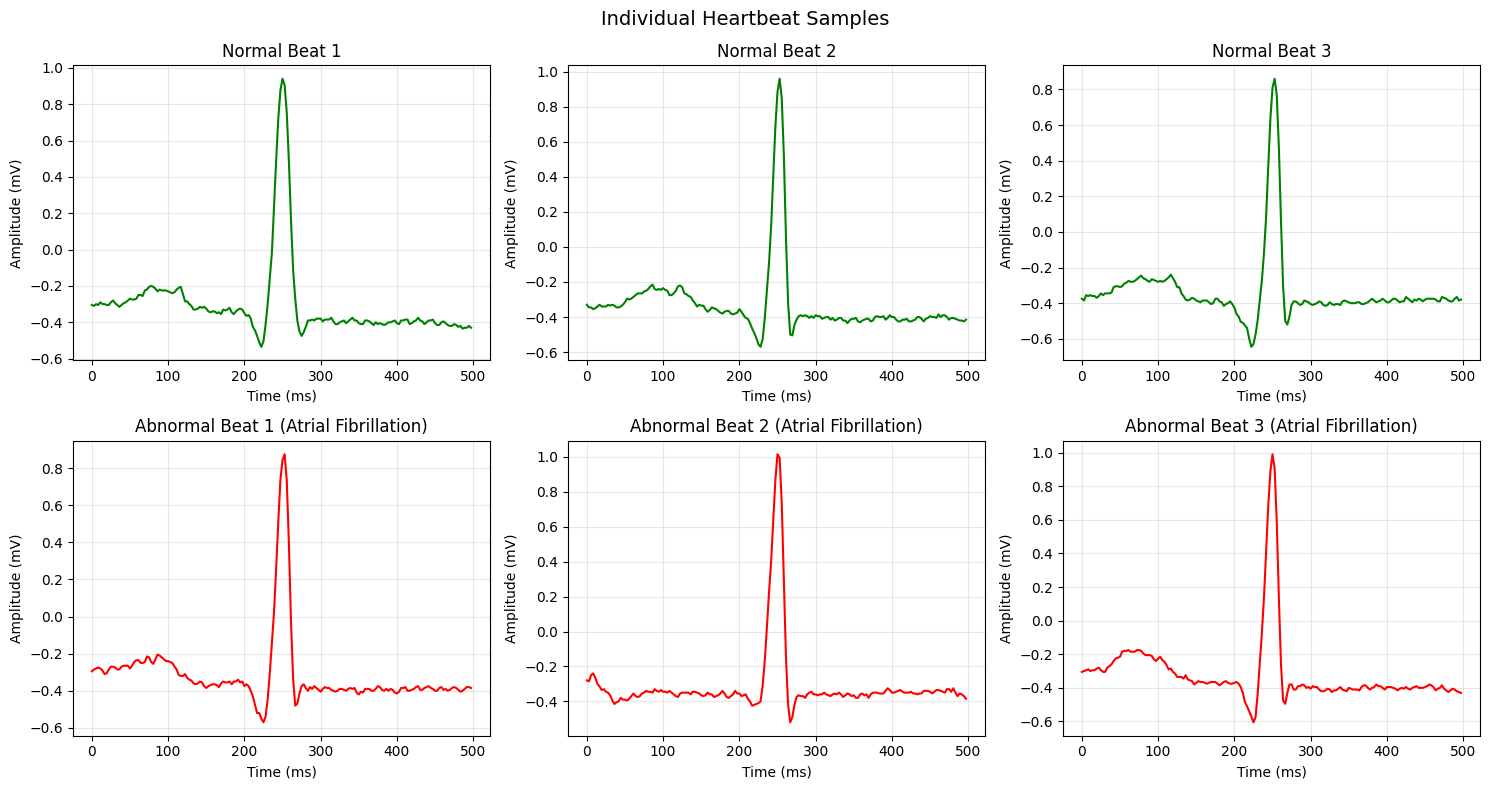

Beats normalized successfully!
Min value: 0.0
Max value: 1.0


In [6]:
# Visualize individual beats and normalize

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Individual Heartbeat Samples', fontsize=14)

time_ms = np.arange(180) / record.fs * 1000  # time in milliseconds

# Plot 3 normal beats
normal_idx = np.where(labels == 0)[0]
for i in range(3):
    axes[0, i].plot(time_ms, beats[normal_idx[i]], color='green', linewidth=1.5)
    axes[0, i].set_title(f'Normal Beat {i+1}')
    axes[0, i].set_xlabel('Time (ms)')
    axes[0, i].set_ylabel('Amplitude (mV)')
    axes[0, i].grid(True, alpha=0.3)

# Plot 3 abnormal beats
abnormal_idx = np.where(labels == 1)[0]
for i in range(3):
    axes[1, i].plot(time_ms, beats[abnormal_idx[i]], color='red', linewidth=1.5)
    axes[1, i].set_title(f'Abnormal Beat {i+1} (Atrial Fibrillation)')
    axes[1, i].set_xlabel('Time (ms)')
    axes[1, i].set_ylabel('Amplitude (mV)')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Normalize beats
def normalize_beats(beats):
    normalized = np.zeros_like(beats)
    for i in range(len(beats)):
        min_val = beats[i].min()
        max_val = beats[i].max()
        if max_val - min_val != 0:
            normalized[i] = (beats[i] - min_val) / (max_val - min_val)
        else:
            normalized[i] = beats[i]
    return normalized

beats_normalized = normalize_beats(beats)
print("Beats normalized successfully!")
print("Min value:", beats_normalized.min())
print("Max value:", beats_normalized.max())

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils import resample

# Handle class imbalance — oversample abnormal beats
beats_normal = beats_normalized[labels == 0]
beats_abnormal = beats_normalized[labels == 1]
labels_normal = labels[labels == 0]
labels_abnormal = labels[labels == 1]

# Upsample abnormal beats to match normal
beats_abnormal_upsampled, labels_abnormal_upsampled = resample(
    beats_abnormal, labels_abnormal,
    replace=True,
    n_samples=len(beats_normal),
    random_state=42
)

# Combine
X_balanced = np.vstack([beats_normal, beats_abnormal_upsampled])
y_balanced = np.hstack([labels_normal, labels_abnormal_upsampled])

print("Balanced dataset:")
print("Normal beats:", np.sum(y_balanced == 0))
print("Abnormal beats:", np.sum(y_balanced == 1))
print("Total:", len(y_balanced))

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nRandom Forest on ECG beats:")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Abnormal']))

Balanced dataset:
Normal beats: 2237
Abnormal beats: 2237
Total: 4474

Random Forest on ECG beats:
Accuracy : 1.0000
F1 Score : 1.0000

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       459
    Abnormal       1.00      1.00      1.00       436

    accuracy                           1.00       895
   macro avg       1.00      1.00      1.00       895
weighted avg       1.00      1.00      1.00       895



In [8]:
# Save results summary
print("=== Week 4 Summary ===")
print("Dataset: MIT-BIH Arrhythmia Database (Record 100)")
print("Sampling frequency: 360 Hz")
print("Total beats extracted: 2270")
print("Beat window: 180 samples (500ms)")
print("Classes: Normal vs Atrial Fibrillation")
print("Model: Random Forest (100 trees)")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nNext step: Load multiple records for better generalization")
print("Next step: Build 1D CNN in PyTorch for ECG classification")

=== Week 4 Summary ===
Dataset: MIT-BIH Arrhythmia Database (Record 100)
Sampling frequency: 360 Hz
Total beats extracted: 2270
Beat window: 180 samples (500ms)
Classes: Normal vs Atrial Fibrillation
Model: Random Forest (100 trees)
Accuracy: 1.0000
F1 Score: 1.0000

Next step: Load multiple records for better generalization
Next step: Build 1D CNN in PyTorch for ECG classification
